# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [31]:
# ============================================================
# ML-10 — Setup
# ============================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

RANDOM_STATE = 42

print("ML-10 setup complete.")

# ============================================================
# Load the FlyRank dataset
# ============================================================

DATA_PATH = "/content/content_refresh_anonymized.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

ML-10 setup complete.
Dataset loaded successfully.
Dataset shape: (30000, 44)


In [32]:
 # ============================================================
# Create target
# ============================================================

df["target"] = (
    df["trend_direction"] == "down"
).astype(int)

print("Target created.")
print("\nTarget distribution:")
print(df["target"].value_counts())

print(
    "\nDeclining base rate:",
    round(df["target"].mean(), 4)
)

Target created.

Target distribution:
target
1    16262
0    13738
Name: count, dtype: int64

Declining base rate: 0.5421


In [33]:
# ============================================================
# Prepare leakage-safe features
# ============================================================

drop_cols = [
    "content_id",
    "client_id",
    "trend_direction",
    "trend_pct",
    "target",
    "impressions_last_30d",
    "clicks_last_30d",
    "sessions_last_30d",
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d"
]

X_raw = df.drop(columns=drop_cols)

X = pd.get_dummies(
    X_raw,
    dummy_na=True
)

X = X.fillna(0)

y = df["target"]

groups = df["client_id"]

print("Feature preparation complete.")
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature preparation complete.
Feature matrix shape: (30000, 76)
Target shape: (30000,)


In [34]:
# ============================================================
# Grouped validation split
# ============================================================

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Grouped split created.")
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print(
    "Training clients:",
    groups.iloc[train_idx].nunique()
)
print(
    "Testing clients:",
    groups.iloc[test_idx].nunique()
)

Grouped split created.
Training rows: 23837
Testing rows: 6163
Training clients: 25
Testing clients: 7


In [35]:
# ============================================================
# Train Random Forest
# ============================================================

rf_group = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_group.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [36]:
# ============================================================
# Calculate grouped validation metrics
# ============================================================

pred_group = rf_group.predict(X_test)

group_accuracy = accuracy_score(
    y_test,
    pred_group
)

group_precision = precision_score(
    y_test,
    pred_group,
    zero_division=0
)

group_recall = recall_score(
    y_test,
    pred_group,
    zero_division=0
)

group_f1 = f1_score(
    y_test,
    pred_group,
    zero_division=0
)

print("GROUPED VALIDATION RESULTS")
print("=" * 50)

print("Accuracy :", round(group_accuracy, 3))
print("Precision:", round(group_precision, 3))
print("Recall   :", round(group_recall, 3))
print("F1 Score :", round(group_f1, 3))

GROUPED VALIDATION RESULTS
Accuracy : 0.572
Precision: 0.577
Recall   : 0.613
F1 Score : 0.594


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [44]:
# ============================================================
# SECTION 1 — Generate decline-risk scores
# ============================================================

# Find the probability column corresponding to class 1 = declining
decline_class_index = list(
    rf_group.classes_
).index(1)

all_probabilities = rf_group.predict_proba(X)

df["decline_risk_score"] = (
    all_probabilities[:, decline_class_index]
)

print("Decline-risk scores generated.")

print(
    "Minimum:",
    round(df["decline_risk_score"].min(), 3)
)

print(
    "Maximum:",
    round(df["decline_risk_score"].max(), 3)
)


# ============================================================
# Create practical action tiers
# ============================================================

def assign_action_tier(score):

    if score >= 0.75:
        return "Priority review"

    elif score >= 0.60:
        return "Review"

    elif score >= 0.45:
        return "Monitor"

    else:
        return "Lower priority"


df["action_tier"] = (
    df["decline_risk_score"]
    .apply(assign_action_tier)
)

print("Action tiers created.")

display(
    df["action_tier"].value_counts()
)


# ============================================================
# Create human-readable reason codes
# ============================================================

def build_reason_codes(row):

    reasons = []

    # Model signal
    if row["decline_risk_score"] >= 0.75:
        reasons.append("HIGH_DECLINE_RISK")

    # Freshness signal
    if "freshness_tier" in row.index:
        if pd.notna(row["freshness_tier"]):

            freshness_value = str(
                row["freshness_tier"]
            ).lower()

            if (
                "stale" in freshness_value
                or "old" in freshness_value
            ):
                reasons.append("CONTENT_FRESHNESS")

    # CTR signal
    if "ctr" in row.index:

        if pd.notna(row["ctr"]):

            if row["ctr"] < df["ctr"].median():
                reasons.append("LOW_CTR")

    # Visibility signal
    if "impressions_90d" in row.index:

        if pd.notna(row["impressions_90d"]):

            if (
                row["impressions_90d"]
                >= df["impressions_90d"].median()
            ):
                reasons.append(
                    "MEANINGFUL_VISIBILITY"
                )

    # Fallback
    if len(reasons) == 0:
        reasons.append("MONITOR")

    return "|".join(reasons)


df["reason_codes"] = df.apply(
    build_reason_codes,
    axis=1
)

print("Reason codes created.")

display(
    df[
        [
            "decline_risk_score",
            "action_tier",
            "reason_codes"
        ]
    ].head(10)
)



# ============================================================
# Map action tiers to recommended editorial actions
# ============================================================

action_map = {

    "Priority review":
        "Review content freshness, search intent, accuracy, and update opportunity first.",

    "Review":
        "Review the page for meaningful content or freshness improvements.",

    "Monitor":
        "Monitor performance and reassess if decline signals strengthen.",

    "Lower priority":
        "No immediate refresh recommendation; retain for monitoring."
}

df["recommended_action"] = (
    df["action_tier"].map(action_map)
)

print("Recommended actions created.")

display(
    df[
        [
            "decline_risk_score",
            "action_tier",
            "reason_codes",
            "recommended_action"
        ]
    ].head(10)
)



# ============================================================
# Build the ranked action queue
# ============================================================

queue = df.sort_values(
    "decline_risk_score",
    ascending=False
).copy()

queue["priority_rank"] = (
    np.arange(len(queue)) + 1
)

base_queue_columns = [
    "priority_rank",
    "decline_risk_score",
    "action_tier",
    "reason_codes",
    "recommended_action"
]

optional_columns = [
    "archetype",
    "content_age_days",
    "days_since_last_update",
    "impressions_90d",
    "ctr",
    "avg_position"
]

queue_columns = base_queue_columns + [
    col
    for col in optional_columns
    if col in queue.columns
]

queue = queue[queue_columns]

print("Ranked action queue created.")
print("Number of rows:", len(queue))

display(queue.head(20))

Decline-risk scores generated.
Minimum: 0.0
Maximum: 1.0
Action tiers created.


,count
action_tier,
Priority review,13054
Lower priority,12846
Review,2199
Monitor,1901


Reason codes created.


,decline_risk_score,action_tier,reason_codes
0,0.54,Monitor,MEANINGFUL_VISIBILITY
1,0.42,Lower priority,LOW_CTR|MEANINGFUL_VISIBILITY
2,0.97,Priority review,HIGH_DECLINE_RISK|MEANINGFUL_VISIBILITY
3,0.14,Lower priority,MEANINGFUL_VISIBILITY
4,0.91,Priority review,HIGH_DECLINE_RISK|MEANINGFUL_VISIBILITY
5,0.59,Monitor,LOW_CTR|MEANINGFUL_VISIBILITY
6,0.91,Priority review,HIGH_DECLINE_RISK|LOW_CTR
7,0.21,Lower priority,LOW_CTR|MEANINGFUL_VISIBILITY
8,0.86,Priority review,HIGH_DECLINE_RISK|MEANINGFUL_VISIBILITY
9,0.95,Priority review,HIGH_DECLINE_RISK|MEANINGFUL_VISIBILITY


Recommended actions created.


,decline_risk_score,action_tier,reason_codes,recommended_action
0,0.54,Monitor,MEANINGFUL_VISIBILITY,Monitor performance and reassess if decline si...
1,0.42,Lower priority,LOW_CTR|MEANINGFUL_VISIBILITY,No immediate refresh recommendation; retain fo...
2,0.97,Priority review,HIGH_DECLINE_RISK|MEANINGFUL_VISIBILITY,"Review content freshness, search intent, accur..."
3,0.14,Lower priority,MEANINGFUL_VISIBILITY,No immediate refresh recommendation; retain fo...
4,0.91,Priority review,HIGH_DECLINE_RISK|MEANINGFUL_VISIBILITY,"Review content freshness, search intent, accur..."
5,0.59,Monitor,LOW_CTR|MEANINGFUL_VISIBILITY,Monitor performance and reassess if decline si...
6,0.91,Priority review,HIGH_DECLINE_RISK|LOW_CTR,"Review content freshness, search intent, accur..."
7,0.21,Lower priority,LOW_CTR|MEANINGFUL_VISIBILITY,No immediate refresh recommendation; retain fo...
8,0.86,Priority review,HIGH_DECLINE_RISK|MEANINGFUL_VISIBILITY,"Review content freshness, search intent, accur..."
9,0.95,Priority review,HIGH_DECLINE_RISK|MEANINGFUL_VISIBILITY,"Review content freshness, search intent, accur..."


Ranked action queue created.
Number of rows: 30000


,priority_rank,decline_risk_score,action_tier,reason_codes,recommended_action,content_age_days,days_since_last_update,impressions_90d,ctr,avg_position
22740,1,1.0,Priority review,HIGH_DECLINE_RISK|MEANINGFUL_VISIBILITY,"Review content freshness, search intent, accur...",225,20,3427,0.20,15.8
6830,2,1.0,Priority review,HIGH_DECLINE_RISK|MEANINGFUL_VISIBILITY,"Review content freshness, search intent, accur...",132,20,3731,0.08,18.5
19124,3,1.0,Priority review,HIGH_DECLINE_RISK|MEANINGFUL_VISIBILITY,"Review content freshness, search intent, accur...",225,20,7144,0.07,15.6
2431,4,1.0,Priority review,HIGH_DECLINE_RISK|LOW_CTR|MEANINGFUL_VISIBILITY,"Review content freshness, search intent, accur...",144,104,1845,0.00,28.7
19103,5,1.0,Priority review,HIGH_DECLINE_RISK|MEANINGFUL_VISIBILITY,"Review content freshness, search intent, accur...",147,20,2357,0.08,22.9
1240,6,1.0,Priority review,HIGH_DECLINE_RISK|MEANINGFUL_VISIBILITY,"Review content freshness, search intent, accur...",132,20,21332,0.07,30.0
19207,7,1.0,Priority review,HIGH_DECLINE_RISK|MEANINGFUL_VISIBILITY,"Review content freshness, search intent, accur...",333,104,2228,0.09,34.2
19226,8,1.0,Priority review,HIGH_DECLINE_RISK|LOW_CTR,"Review content freshness, search intent, accur...",169,20,588,0.00,4.4
11529,9,1.0,Priority review,HIGH_DECLINE_RISK|MEANINGFUL_VISIBILITY,"Review content freshness, search intent, accur...",225,20,12892,0.83,10.6
6835,10,1.0,Priority review,HIGH_DECLINE_RISK|MEANINGFUL_VISIBILITY,"Review content freshness, search intent, accur...",224,20,3216,0.12,26.5


## 2. Intended use and limits

### Intended use

This output is a decision-support tool for prioritizing editorial review.

Content editors or SEO analysts can use the queue to determine which pages deserve attention first when review capacity is limited.

The model does not decide what content should be changed. It identifies pages that may deserve earlier human investigation.

### Limits

The model was evaluated using a grouped-by-client validation split.

The validation results should be reported from the fresh notebook run. The declining-class base rate should also be reported because accuracy alone can be misleading when one class represents a large share of the data.

The analysis is observational and directional. The score does not prove that a page will decline, that refreshing it will improve performance, or that any observed relationship represents a Google ranking factor.

The output should therefore be used for decision-support and human prioritization, not autonomous content changes.

In [38]:
# ============================================================
# SECTION 2 — Intended Use and Limits
# ============================================================

print("INTENDED USE")
print("=" * 60)

print(
    "Primary users: Content editors or SEO analysts"
)

print(
    "Decision supported: Which pages should receive "
    "human review first"
)

print(
    "Output: Ranked queue with decline-risk score, "
    "reason codes, and recommended review action"
)

print(
    "Purpose: Prioritize limited editorial review capacity"
)

print("\nVALIDATION PERFORMANCE")
print("=" * 60)

print(
    "Grouped validation accuracy:",
    round(group_accuracy, 3)
)

print(
    "Grouped validation precision:",
    round(group_precision, 3)
)

print(
    "Grouped validation recall:",
    round(group_recall, 3)
)

print(
    "Grouped validation F1:",
    round(group_f1, 3)
)

print(
    "\nDeclining-class base rate:",
    round(df["target"].mean(), 4)
)

print("\nImportant limitations:")
print("- Observational analysis")
print("- Directional decision-support")
print("- No causal claims")
print("- No claim about Google's ranking algorithm")
print("- Human review remains required")

INTENDED USE
Primary users: Content editors or SEO analysts
Decision supported: Which pages should receive human review first
Output: Ranked queue with decline-risk score, reason codes, and recommended review action
Purpose: Prioritize limited editorial review capacity

VALIDATION PERFORMANCE
Grouped validation accuracy: 0.572
Grouped validation precision: 0.577
Grouped validation recall: 0.613
Grouped validation F1: 0.594

Declining-class base rate: 0.5421

Important limitations:
- Observational analysis
- Directional decision-support
- No causal claims
- No claim about Google's ranking algorithm
- Human review remains required


## 3. Human review + the no-go list

### Human review rule

The model recommends where to look first; a human decides what to do.

Before acting, an editor should inspect the content, search intent, factual accuracy, freshness, business importance, and the reason codes.

Mixed-signal or low-confidence cases should receive additional human review.

### What should not be automated

Content rewriting, publishing, deletion, metadata changes, and other consequential editorial decisions should not be automated from this score alone.

The model is a prioritization aid, not an autonomous content-management system.

In [39]:
# ============================================================
# SECTION 3 — Human Review + No-Go List
# ============================================================

human_review_rules = [

    "Check the page's actual content before making a refresh decision.",

    "Confirm that the page still satisfies the intended search intent.",

    "Check whether the content is factually accurate and up to date.",

    "Review the reason codes rather than relying only on the model score.",

    "Consider business importance and editorial priorities.",

    "Check whether recent changes or unusual events could explain the observed signals.",

    "Treat low-confidence or mixed-signal cases as manual-review cases.",

    "Record the editor's final decision separately from the model recommendation."
]

print("HUMAN REVIEW RULES")
print("=" * 60)

for i, rule in enumerate(
    human_review_rules,
    start=1
):

    print(f"{i}. {rule}")


no_go_list = [

    "Do not automatically rewrite or publish content.",

    "Do not automatically delete pages.",

    "Do not automatically change titles or metadata.",

    "Do not use the score as proof of a Google ranking factor.",

    "Do not use the score to make causal claims.",

    "Do not expose client names, domains, URLs, private queries, or credentials.",

    "Do not treat the model score as a guaranteed probability of future traffic loss."
]

print("\nNO-GO LIST")
print("=" * 60)

for item in no_go_list:

    print("-", item)

HUMAN REVIEW RULES
1. Check the page's actual content before making a refresh decision.
2. Confirm that the page still satisfies the intended search intent.
3. Check whether the content is factually accurate and up to date.
4. Review the reason codes rather than relying only on the model score.
5. Consider business importance and editorial priorities.
6. Check whether recent changes or unusual events could explain the observed signals.
7. Treat low-confidence or mixed-signal cases as manual-review cases.
8. Record the editor's final decision separately from the model recommendation.

NO-GO LIST
- Do not automatically rewrite or publish content.
- Do not automatically delete pages.
- Do not automatically change titles or metadata.
- Do not use the score as proof of a Google ranking factor.
- Do not use the score to make causal claims.
- Do not expose client names, domains, URLs, private queries, or credentials.
- Do not treat the model score as a guaranteed probability of future traffic

## 4. Monitoring / retrain triggers

### Decay / refresh insight

The freshness analysis reports the observed share of pages labelled as declining across freshness groups.

This is an association in the historical dataset, not evidence that refreshing a page causes better performance.

The result can provide directional evidence for deciding whether freshness should remain part of the editorial review framework.

If the relationship changes materially in future data, the analysis should be repeated.

### Monitoring

The model should be reconsidered when the data distribution changes substantially, when the declining-class base rate changes materially, when the ranked queue becomes unstable, or when validation performance deteriorates.

Retraining should follow a fresh validation check rather than being triggered only by elapsed time.

Observed decline rate by freshness tier:


,freshness_tier,pages,declining_pages,decline_rate
3,91-180,9171,5604,0.611
2,31-90,175,103,0.589
0,0-30,20480,10473,0.511
1,181+,174,82,0.471


Observed decline rate by age tier:


,age_tier,pages,declining_pages,decline_rate
1,31-90,492,329,0.669
3,91-180,11780,7369,0.626
0,181-365,11368,5853,0.515
2,365+,6360,2711,0.426


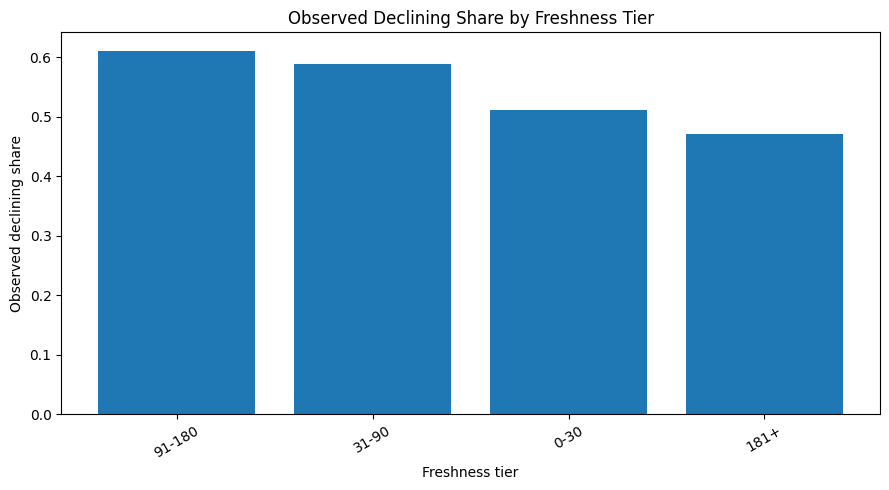

MONITORING / RETRAIN TRIGGERS
Performance drift:
Re-evaluate the model if grouped validation performance falls materially from the current benchmark.

Feature drift:
Monitor changes in the distributions of major input features.

Base-rate drift:
Monitor changes in the proportion of pages labelled as declining.

Queue stability:
Check whether the highest-priority pages change substantially between consecutive runs without corresponding changes in the underlying data.

Freshness drift:
Recheck the observed relationship between content freshness and decline when the underlying content mix changes.

Retraining trigger:
Retrain and revalidate when substantial feature drift, base-rate drift, or sustained performance deterioration is observed.



In [40]:
# ============================================================
# SECTION 4 — Freshness / Decay Analysis
# ============================================================

if "freshness_tier" in df.columns:

    freshness_summary = (
        df.groupby(
            "freshness_tier",
            dropna=False
        )
        .agg(
            pages=("target", "size"),
            declining_pages=("target", "sum"),
            decline_rate=("target", "mean")
        )
        .reset_index()
        .sort_values(
            "decline_rate",
            ascending=False
        )
    )

    print("Observed decline rate by freshness tier:")

    display(
        freshness_summary.round(3)
    )

else:

    freshness_summary = pd.DataFrame()

    print(
        "freshness_tier is not available "
        "in this dataset."
    )




     # ============================================================
# Content age analysis
# ============================================================

if "age_tier" in df.columns:

    age_summary = (
        df.groupby(
            "age_tier",
            dropna=False
        )
        .agg(
            pages=("target", "size"),
            declining_pages=("target", "sum"),
            decline_rate=("target", "mean")
        )
        .reset_index()
        .sort_values(
            "decline_rate",
            ascending=False
        )
    )

    print("Observed decline rate by age tier:")

    display(
        age_summary.round(3)
    )

else:

    age_summary = pd.DataFrame()

    print(
        "age_tier is not available "
        "in this dataset."
    )

    # ============================================================
# Freshness figure
# ============================================================

if not freshness_summary.empty:

    plot_data = freshness_summary.dropna(
        subset=["decline_rate"]
    ).copy()

    plt.figure(figsize=(9, 5))

    plt.bar(
        plot_data["freshness_tier"].astype(str),
        plot_data["decline_rate"]
    )

    plt.ylabel("Observed declining share")
    plt.xlabel("Freshness tier")

    plt.title(
        "Observed Declining Share by Freshness Tier"
    )

    plt.xticks(rotation=30)

    plt.tight_layout()

    plt.show()

else:

    plot_data = pd.DataFrame()

    print(
        "Freshness figure skipped because "
        "freshness_tier is unavailable."
    )


    # ============================================================
# Monitoring / retrain triggers
# ============================================================

monitoring_triggers = {

    "Performance drift":
        "Re-evaluate the model if grouped validation performance falls materially from the current benchmark.",

    "Feature drift":
        "Monitor changes in the distributions of major input features.",

    "Base-rate drift":
        "Monitor changes in the proportion of pages labelled as declining.",

    "Queue stability":
        "Check whether the highest-priority pages change substantially between consecutive runs without corresponding changes in the underlying data.",

    "Freshness drift":
        "Recheck the observed relationship between content freshness and decline when the underlying content mix changes.",

    "Retraining trigger":
        "Retrain and revalidate when substantial feature drift, base-rate drift, or sustained performance deterioration is observed."
}

print("MONITORING / RETRAIN TRIGGERS")
print("=" * 60)

for key, value in monitoring_triggers.items():

    print(f"{key}:")
    print(value)
    print()

## 5. Exports for the paper

### Export purpose

The ranked action queue and supporting analysis are exported so that the final research paper can reuse the same outputs generated by this notebook.

The queue is treated as an analytical output rather than a production content-management dataset.

The queue CSV should remain out of Git if the repository's leak-guard requires data files to stay uncommitted. Reusable figures and metrics receipts can be committed according to the repository instructions.

Output directories created.
/content/work/outputs
/content/work/figures
Ranked queue saved to:
/content/work/outputs/w07_ranked_action_queue.csv
Freshness summary saved to:
/content/work/outputs/w07_freshness_summary.csv


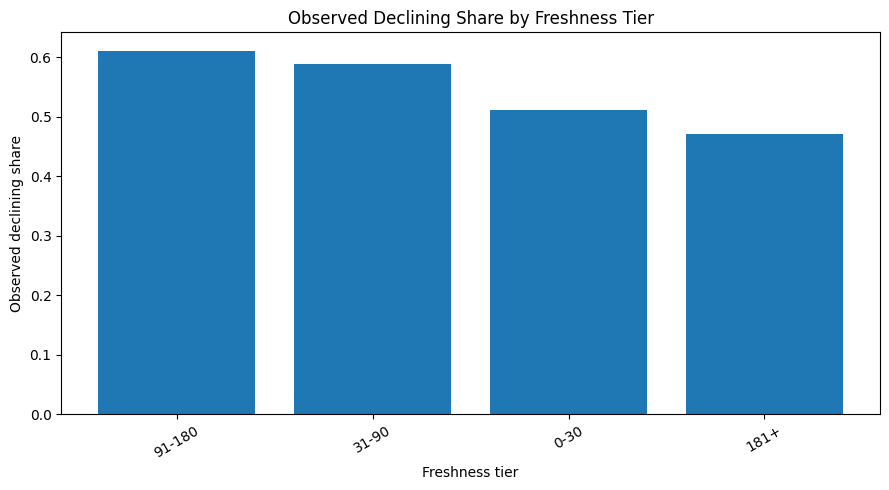

Figure saved to:
/content/work/figures/w07_freshness_decline_rate.png
Metrics receipt saved to:
/content/work/outputs/w07_metrics_receipt.json


,validation,random_state,random_forest_accuracy,random_forest_precision,random_forest_recall,random_forest_f1,declining_base_rate,dataset_rows,feature_count
0,grouped_by_client,42,0.5723,0.5766,0.6132,0.5943,0.5421,30000,76


In [41]:
 # ============================================================
# SECTION 5 — Create output directories
# ============================================================

OUTPUT_DIR = "/content/work/outputs"
FIGURE_DIR = "/content/work/figures"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

os.makedirs(
    FIGURE_DIR,
    exist_ok=True
)

print("Output directories created.")
print(OUTPUT_DIR)
print(FIGURE_DIR)


# ============================================================
# Export ranked action queue
# ============================================================

queue_path = (
    f"{OUTPUT_DIR}/w07_ranked_action_queue.csv"
)

queue.to_csv(
    queue_path,
    index=False
)

print(
    "Ranked queue saved to:"
)

print(queue_path)


# ============================================================
# Export freshness summary
# ============================================================

freshness_path = (
    f"{OUTPUT_DIR}/w07_freshness_summary.csv"
)

if not freshness_summary.empty:

    freshness_summary.to_csv(
        freshness_path,
        index=False
    )

    print(
        "Freshness summary saved to:"
    )

    print(freshness_path)

else:

    print(
        "Freshness summary not exported "
        "because freshness_tier is unavailable."
    )

    # ============================================================
# Save freshness figure
# ============================================================

figure_path = (
    f"{FIGURE_DIR}/w07_freshness_decline_rate.png"
)

if not freshness_summary.empty:

    plt.figure(figsize=(9, 5))

    plt.bar(
        plot_data["freshness_tier"].astype(str),
        plot_data["decline_rate"]
    )

    plt.ylabel("Observed declining share")
    plt.xlabel("Freshness tier")

    plt.title(
        "Observed Declining Share by Freshness Tier"
    )

    plt.xticks(rotation=30)

    plt.tight_layout()

    plt.savefig(
        figure_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

    print(
        "Figure saved to:"
    )

    print(figure_path)

else:

    print(
        "Figure not saved because "
        "freshness analysis was unavailable."
    )


    # ============================================================
# Save metrics receipt
# ============================================================

metrics_receipt = {

    "validation":
        "grouped_by_client",

    "random_state":
        RANDOM_STATE,

    "random_forest_accuracy":
        round(group_accuracy, 4),

    "random_forest_precision":
        round(group_precision, 4),

    "random_forest_recall":
        round(group_recall, 4),

    "random_forest_f1":
        round(group_f1, 4),

    "declining_base_rate":
        round(df["target"].mean(), 4),

    "dataset_rows":
        int(len(df)),

    "feature_count":
        int(X.shape[1])
}

metrics_path = (
    f"{OUTPUT_DIR}/w07_metrics_receipt.json"
)

with open(
    metrics_path,
    "w"
) as f:

    json.dump(
        metrics_receipt,
        f,
        indent=2
    )

print(
    "Metrics receipt saved to:"
)

print(metrics_path)

display(
    pd.DataFrame(
        [metrics_receipt]
    )
)